In [29]:
import pandas as pd
import numpy as np
import sys
from numba import njit, prange
parent_path = '/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline'
sys.path.append(parent_path)
from SynOmics.processing.metadata import MetaData

metadata_path = "OriginalData/feature_metadata.json"
data_path = "OriginalData/integrated_data_melanoma.csv"

or_df = pd.read_csv(data_path, index_col = 0)
metadata = MetaData.load(metadata_path)
grouped_metadata = MetaData.grouping_features_astype(or_df, metadata)
categorical_features = grouped_metadata.get("ordinal_categorical") + grouped_metadata.get("dummy_categorical") + grouped_metadata.get("missing_categorical")
numerical_features = grouped_metadata.get("numerical")

In [32]:
from SynOmics.processing.preprocessing import DataProcessor
encoded_cat_df, encoders = DataProcessor.encode_ordinal_features(or_df[categorical_features])
num_df = or_df[numerical_features]
processed_df = pd.concat([encoded_cat_df, num_df], axis = 1)

In [33]:
processed_df.to_csv("synthpop/synthpop_processed_data.csv", index=True)

In [34]:
from SynOmics.utils.correlations import MixedCorrelation
from SynOmics.utils.monitoring import monitor_resources

@monitor_resources
def test_speed():
    clean_metadata = MetaData.grouping_features_astype(processed_df, metadata)
    cat_indices = MetaData.get_column_indices(processed_df, categorical_features)
    num_indices = MetaData.get_column_indices(processed_df, numerical_features)
    
    compute_correlations = MixedCorrelation(cat_indices, num_indices, 
                                                  method = "spearman", 
                                                  n_bins = 10,
                                                engine = "auto",
                                                block_cols = 512
                                                 )
    corr_matrix = compute_correlations.compute(processed_df)
    distance_matrix = 1 - np.abs(corr_matrix)
    return distance_matrix
    
distance_matrix = test_speed()

--- System & Process Info ---
Current Date and Time (UTC): 2025-11-11 15:45:30
Current User's Login: trinhtc
CPU Model: x86_64
Physical Cores: 32
Logical Processors: 32
Process RAM before execution: 17867.84 MB

--- GPU Info ---
GPU monitoring failed. Ensure 'nvidia-ml-py' is installed and NVIDIA drivers are accessible.
Error: module 'nvidia_smi' has no attribute 'nvidia_smi_lib'

--- Function Execution ---

--- Resource Usage Summary ---
Execution time: 31.853162 seconds
Process RAM after execution: 21207.07 MB
Process RAM used by function: 3339.23 MB
Average per-core CPU during execution: [46.8, 46.8, 46.8, 45.8, 46.9, 46.5, 46.8, 44.7, 47.0, 44.9, 46.9, 45.6, 89.7, 46.9, 46.6, 46.8, 79.8, 0.0, 46.7, 1.3, 46.9, 0.8, 46.9, 0.1, 46.5, 0.1, 46.8, 0.0, 46.7, 0.0, 46.8, 0.0]
CPU Cores utilized (>10%): 24 of 32




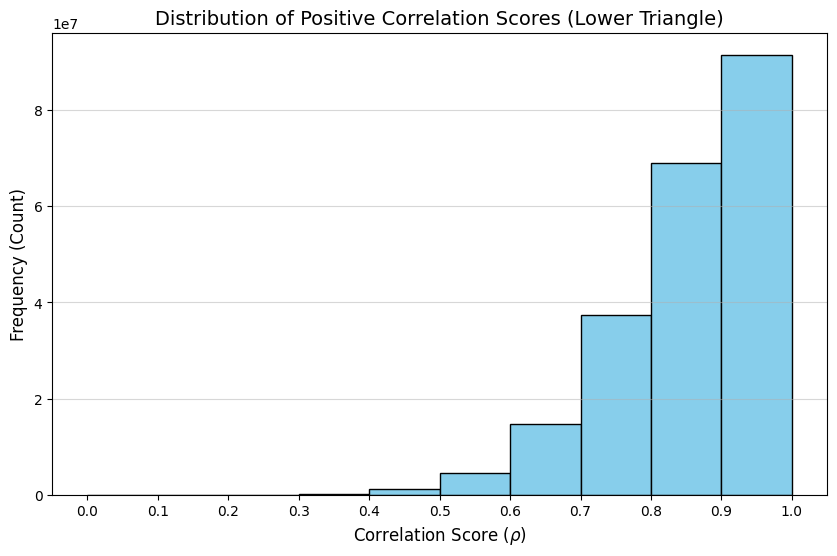

In [35]:
import matplotlib.pyplot as plt

sqr_corr_mat = MixedCorrelation.get_squareform(distance_matrix)
try:
    bins = np.arange(0, 1.1, 0.1)

    plt.figure(figsize=(10, 6))


    plt.hist(sqr_corr_mat, bins=bins, edgecolor='black', color='skyblue', range=(0, 1))

    plt.title('Distribution of Positive Correlation Scores (Lower Triangle)', fontsize=14)
    plt.xlabel('Correlation Score ($\\rho$)', fontsize=12)
    plt.ylabel('Frequency (Count)', fontsize=12)
    plt.xticks(bins) # Set ticks to match bin edges
    plt.grid(axis='y', alpha=0.5)
    plt.show()


except FileNotFoundError:
    print(f"Error: The file '{{file_name}}' was not found. Please check the name and try again.")
except Exception as e:
    print(f"An error occurred: {{e}}")

In [36]:
def binary_correlation_matrix(dist_matrix, threshold, max_per_row=3000):
    """
    Create a binary matrix from a correlation matrix using a threshold.

    Each cell in the matrix is set to 1 if its value is less than the given threshold,
    otherwise it is set to 0. For each row, if the number of 1s exceeds max_per_row,
    only the top max_per_row lowest values are set to 1 and the rest are set to 0.

    Args:
        corr_matrix (Union[np.ndarray, pd.DataFrame]): Input correlation matrix.
        threshold (float): Threshold below which cells are considered satisfied (set to 1).
        max_per_row (int, optional): Maximum number of 1s allowed per row (default is 3000).

    Returns:
        np.ndarray: Binary matrix of the same shape as corr_matrix.

    Raises:
        ValueError: If the input is not a 2D array or DataFrame.
    """
    # Convert to numpy array if dataframe
    if isinstance(dist_matrix, pd.DataFrame):
        arr = dist_matrix.values
    elif isinstance(dist_matrix, np.ndarray):
        arr = dist_matrix
    else:
        raise ValueError("Input must be a numpy array or pandas DataFrame.")

    # Step 1: Apply thresholding
    bin_matrix = (arr <= threshold).astype(int)

    # Step 2: For each row, keep only top max_per_row lowest values as 1 if exceeding the limit
    for i in range(bin_matrix.shape[0]):
        ones_indices = np.where(bin_matrix[i] == 1)[0]
        if len(ones_indices) > max_per_row:
            # Get indices of the actual lowest values (not just any cell < threshold)
            row_values = arr[i, ones_indices]
            lowest_indices = ones_indices[np.argsort(row_values)[:max_per_row]]
            # Reset all to 0, then set only the lowest ones to 1
            bin_matrix[i, ones_indices] = 0
            bin_matrix[i, lowest_indices] = 1

    return bin_matrix

In [37]:
threshold = 0.7
max_per_row = 500
binary_matrix = binary_correlation_matrix(distance_matrix, threshold, max_per_row)

In [38]:
features = or_df.columns.tolist()


# anchors_indices = [features.index(feature) for feature in features if feature in anchors_set]
features_indices = [features.index(feature) for feature in features]

result = {
    str(idx): [
        str(i) for i in np.where(binary_matrix[idx] == 1)[0] 
        if i != idx 
    ]
    for idx in features_indices
}

In [39]:
import networkx as nx

correlation_dict = result
# --- Sắp xếp các features ---
G = nx.Graph(correlation_dict)

# Tính các độ đo trung tâm
degree_centrality = nx.degree_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

# Sắp xếp với nhiều tiêu chí phụ
sorted_features = sorted(
    G.nodes(),
    key=lambda f: (
        -degree_centrality[f], 
        -eigenvector_centrality[f], 
        f
    )
)

In [40]:
# Tạo một map để tra cứu vị trí (index) của mỗi feature một cách nhanh chóng
feature_to_index = {feature: i for i, feature in enumerate(sorted_features)}

num_features = len(sorted_features)
predictor_matrix = np.zeros((num_features, num_features), dtype=int)

# Vòng lặp qua các feature đã sắp xếp để xác định các mối quan hệ
for row_feature in sorted_features:
    # Lấy danh sách các feature tương quan cao với row_feature từ dictionary gốc
    correlated_predictors = correlation_dict.get(row_feature, [])
    
    # Lấy index của feature đang được dự báo (hàng)
    row_idx = feature_to_index[row_feature]
    
    for col_feature in correlated_predictors:
        # Kiểm tra xem feature dự báo (cột) có tồn tại trong danh sách đã sắp xếp không
        if col_feature in feature_to_index:
            col_idx = feature_to_index[col_feature]
            
            # ÁP DỤNG CẢ HAI QUY TẮC:
            # 1. col_idx < row_idx (quy tắc thứ tự)
            # 2. col_feature có trong list tương quan (đã được đảm bảo bởi vòng lặp)
            if col_idx < row_idx:
                predictor_matrix[row_idx, col_idx] = 1

In [41]:
monocity_cols = [np.sum(predictor_matrix[:,i]) for i in range(predictor_matrix.shape[0])]
monocity_rows = [np.sum(predictor_matrix[i,:]) for i in range(predictor_matrix.shape[0])]

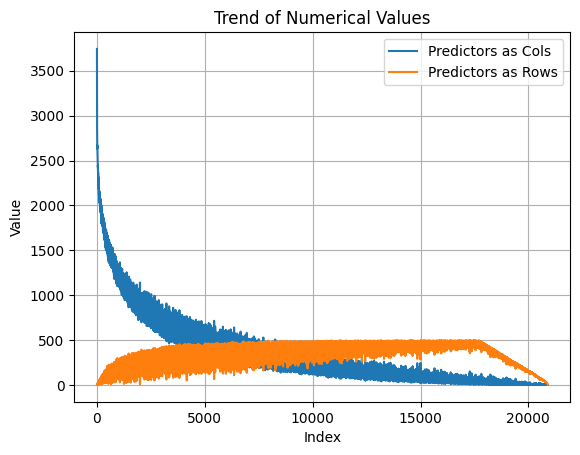

In [47]:
import matplotlib.pyplot as plt


# Line plot
plt.plot(monocity_cols, linestyle='-', label='Predictors as Cols')
plt.plot(monocity_rows, linestyle='-', label='Predictors as Rows')
# Add labels
plt.title("Trend of Numerical Values")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()

In [43]:
np.save("synthpop/predictor_matrix.npy",predictor_matrix)

In [44]:
with open("synthpop/sorted_features.txt", "w") as f:
    for s in sorted_features:
        f.write(str(s) +"\n")

In [48]:
sorted_features_names = [or_df.columns[int(i)] for i in sorted_features]

In [49]:
# Chuyển thành Pandas DataFrame để dễ đọc
predictor_df_from_dict = pd.DataFrame(predictor_matrix, 
                                      index=sorted_features_names, 
                                      columns=sorted_features_names)